<a href="https://colab.research.google.com/github/bugindacodeQ/GSoC-2026-OSIPI-pre-application-prototype-modular-quality-control-pipeline-/blob/main/OSIPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Synthetic ASL data ready.
Shape: (64, 64, 20, 60) | Motion events: [15, 30, 45] | Corrupted vol: 40 | Bad M0 slice: 5


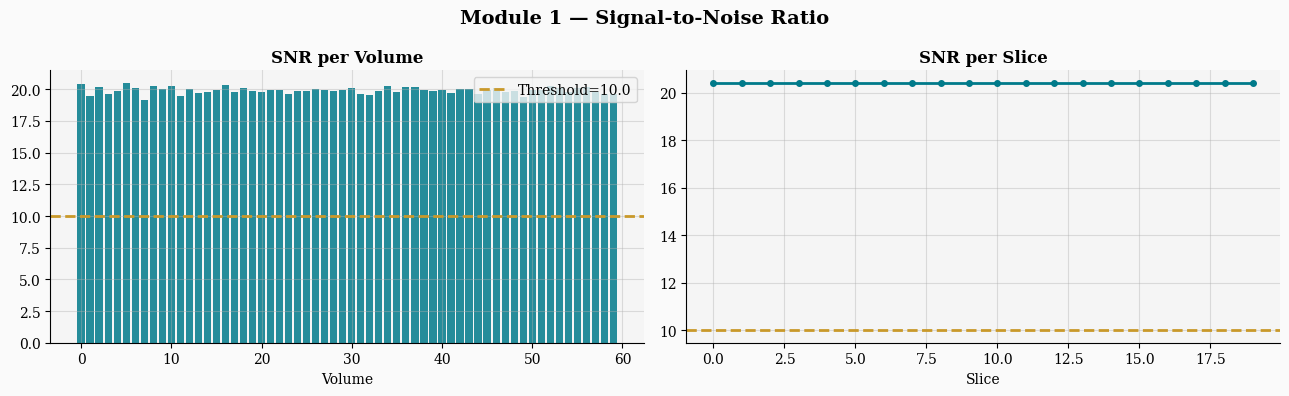

[SNR] Mean: 19.92 | Failed volumes: [] | PASS


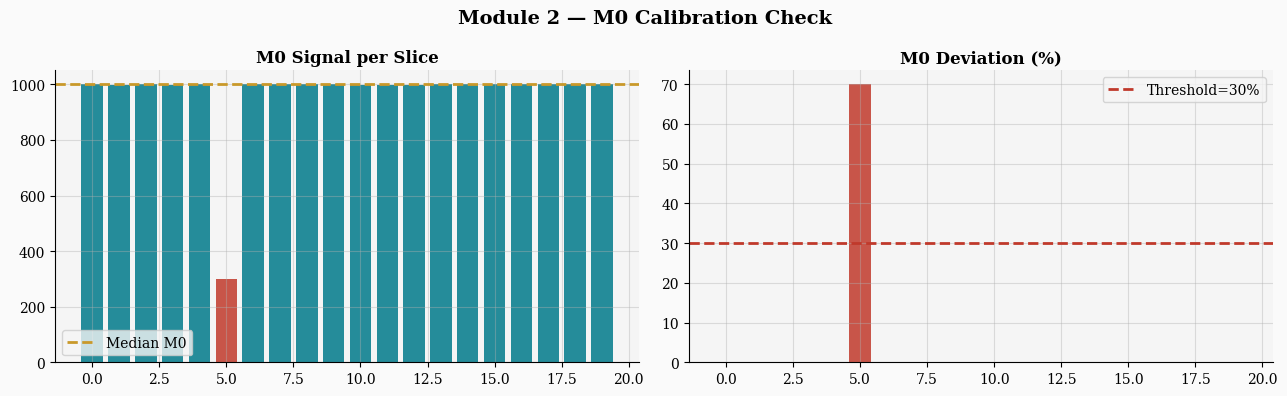

[M0] Flagged slices: [np.int64(5)] | FAIL


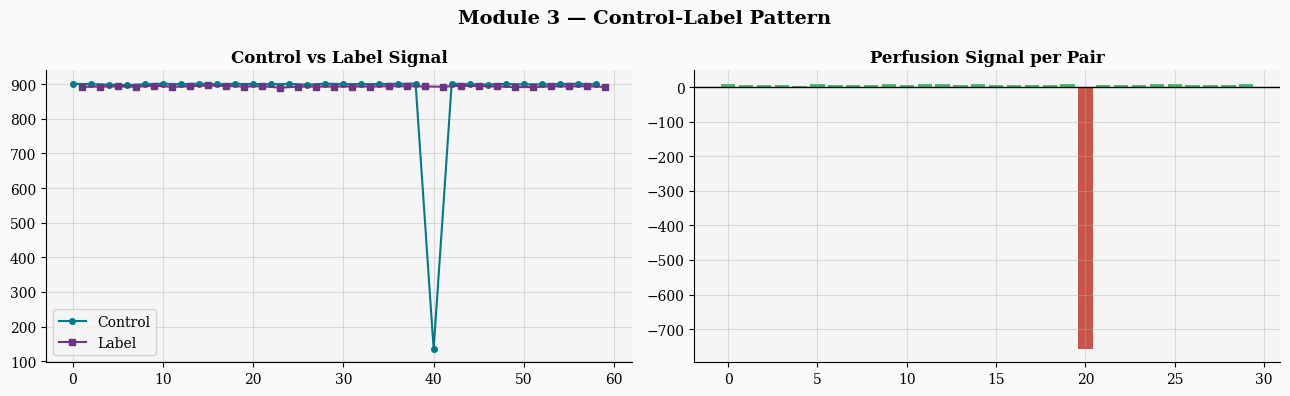

[Pattern] Violations: 1 | PASS


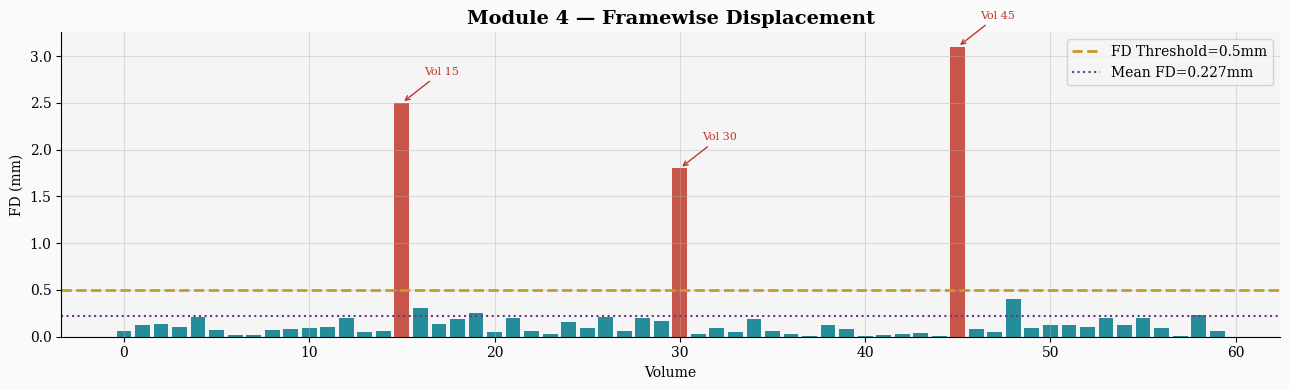

[Motion] Flagged volumes: [np.int64(15), np.int64(30), np.int64(45)] | Mean FD: 0.227mm | FAIL


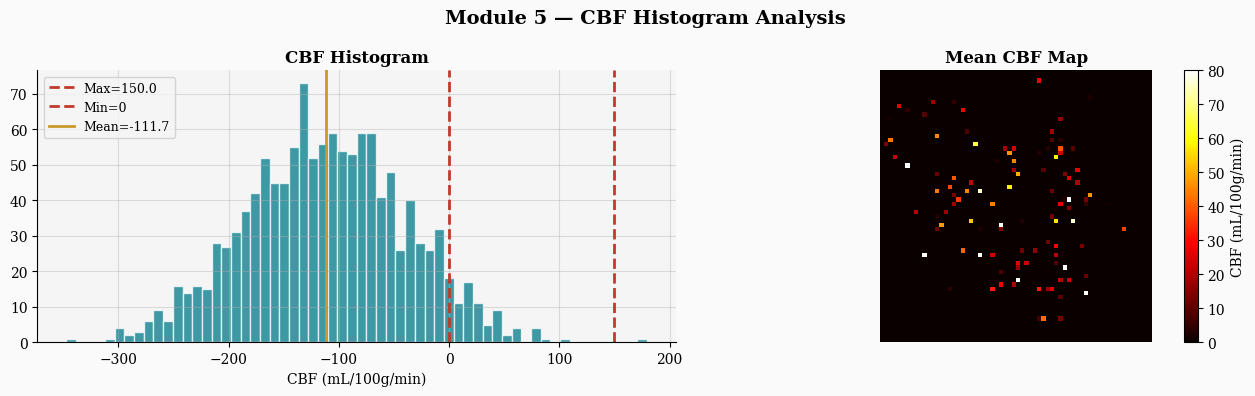

[CBF] Mean: -111.73 | Implausible: 1172 (94.1%) | FAIL


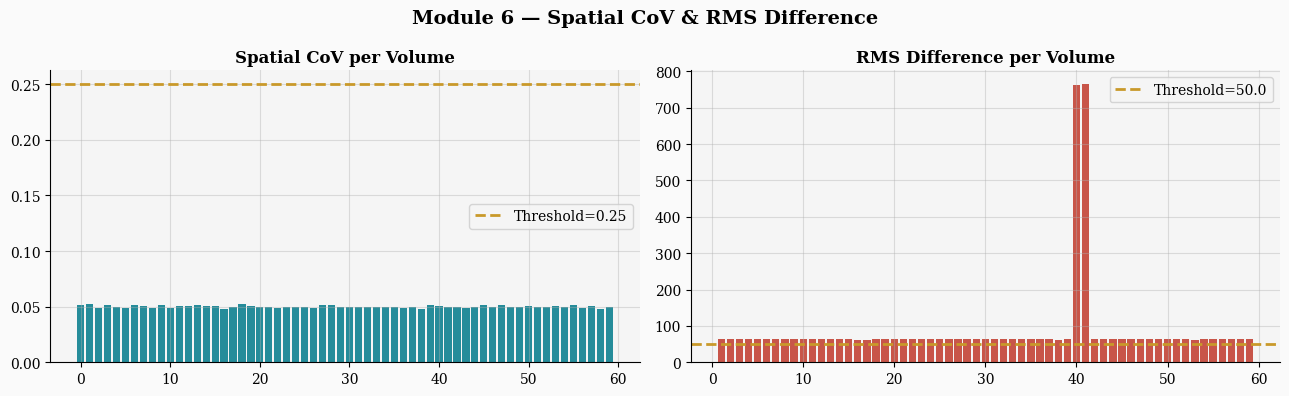

[CoV] Flagged: [] | [RMS] Flagged: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59)]


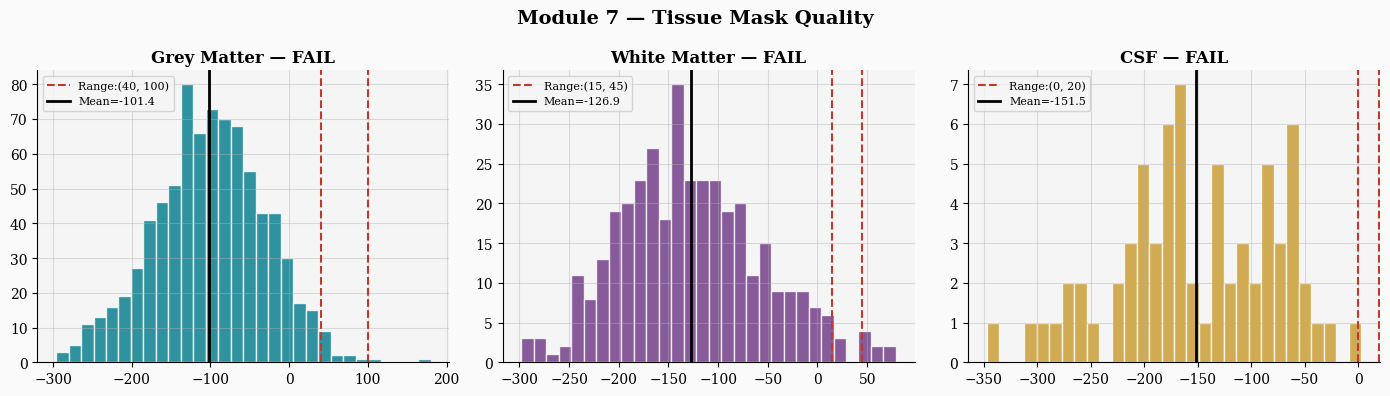

  Grey Matter     | Mean: -101.44 | Expected: (40, 100) | FAIL
  White Matter    | Mean: -126.87 | Expected: (15, 45) | FAIL
  CSF             | Mean: -151.52 | Expected: (0, 20) | FAIL


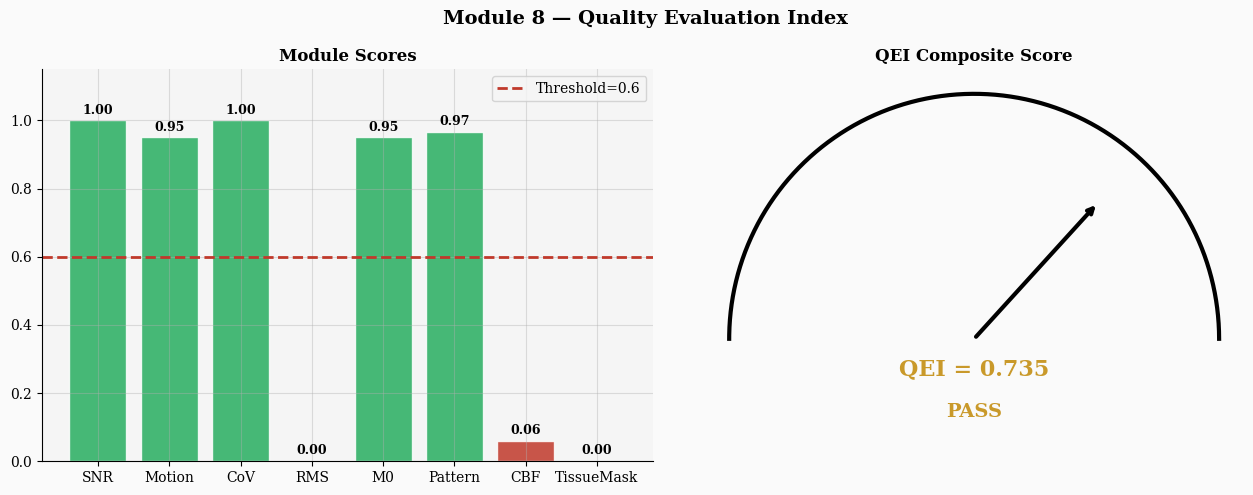


  FINAL QC REPORT — OSIPI QC Toolbox Prototype
  [PASS]  SNR           1.000  (weight=0.20)
  [PASS]  Motion        0.950  (weight=0.20)
  [PASS]  CoV           1.000  (weight=0.10)
  [FAIL]  RMS           0.000  (weight=0.10)
  [PASS]  M0            0.950  (weight=0.15)
  [PASS]  Pattern       0.967  (weight=0.10)
  [FAIL]  CBF           0.059  (weight=0.10)
  [FAIL]  TissueMask    0.000  (weight=0.05)
  QEI SCORE : 0.735
  VERDICT   : PASS — scan acceptable

Author: Ovie Great Ohwoka | github.com/bugindacodeQ


In [1]:
# ============================================================
# OSIPI QC Toolbox — Exploratory Prototype
# Author: Ovie Great Ohwoka | github.com/bugindacodeQ
# GSoC 2026 OSIPI Application
# ============================================================

!pip install numpy scipy matplotlib --quiet

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#F5F5F5',
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'serif', 'axes.titleweight': 'bold',
})
TEAL = '#007A8A'; GOLD = '#C9992A'; RED = '#C0392B'
GREEN = '#27AE60'; PURPLE = '#6C3483'

# ── SYNTHETIC ASL DATA ───────────────────────────────────────
NX, NY, NZ, N_VOLUMES = 64, 64, 20, 60
M0 = 1000.0; sigma = M0 / 20.0
mid_slice = NZ // 2

cx, cy = NX//2, NY//2
Y_g, X_g = np.ogrid[:NX, :NY]
gm_mask  = ((X_g-cx)**2 + (Y_g-cy)**2 < 20**2)
wm_mask  = ((X_g-cx)**2 + (Y_g-cy)**2 < 12**2)
csf_mask = ((X_g-cx)**2 + (Y_g-cy)**2 < 5**2)
gm_mask  = gm_mask & ~wm_mask
wm_mask  = wm_mask & ~csf_mask
brain_mask = gm_mask | wm_mask | csf_mask

cbf_true = np.zeros((NX, NY))
cbf_true[gm_mask]  = np.random.normal(60, 10, gm_mask.sum())
cbf_true[wm_mask]  = np.random.normal(25,  5, wm_mask.sum())
cbf_true[csf_mask] = np.random.normal( 5,  2, csf_mask.sum())
cbf_true = np.clip(cbf_true, 0, None)
delta_M  = cbf_true / 6000 * M0

asl_series = np.zeros((NX, NY, NZ, N_VOLUMES))
motion_fd  = np.zeros(N_VOLUMES)
motion_events = {15: 2.5, 30: 1.8, 45: 3.1}

for t in range(N_VOLUMES):
    is_label = (t % 2 == 1)
    vol = M0 - (delta_M if is_label else 0) + np.random.normal(0, sigma, (NX, NY))
    if t in motion_events:
        motion_fd[t] = motion_events[t]
        vol = np.roll(vol, int(motion_events[t]*2), axis=0)
    else:
        motion_fd[t] = abs(np.random.normal(0, 0.15))
    if t == 40:
        vol *= 0.15
    for z in range(NZ):
        asl_series[:,:,z,t] = vol * (1 - 0.01*z)

M0_image = np.full((NX,NY,NZ), M0) + np.random.normal(0, sigma*0.5, (NX,NY,NZ))
M0_image[:,:,5] *= 0.3

print("Synthetic ASL data ready.")
print(f"Shape: {asl_series.shape} | Motion events: {list(motion_events.keys())} | Corrupted vol: 40 | Bad M0 slice: 5")

# ── MODULE 1: SNR ────────────────────────────────────────────
SNR_THRESHOLD = 10.0
snr_per_volume = np.array([
    asl_series[:,:,mid_slice,t][brain_mask].mean() /
    (asl_series[:,:,mid_slice,t][~brain_mask].std() + 1e-8)
    for t in range(N_VOLUMES)
])
failed_snr = np.where(snr_per_volume < SNR_THRESHOLD)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(N_VOLUMES), snr_per_volume,
            color=[RED if s < SNR_THRESHOLD else TEAL for s in snr_per_volume], alpha=0.85)
axes[0].axhline(SNR_THRESHOLD, color=GOLD, lw=2, ls='--', label=f'Threshold={SNR_THRESHOLD}')
axes[0].set_title('SNR per Volume'); axes[0].set_xlabel('Volume'); axes[0].legend()

snr_per_slice = np.array([
    asl_series[:,:,z,0][brain_mask].mean() /
    (asl_series[:,:,z,0][~brain_mask].std() + 1e-8)
    for z in range(NZ)
])
axes[1].plot(range(NZ), snr_per_slice, 'o-', color=TEAL, lw=2, ms=4)
axes[1].axhline(SNR_THRESHOLD, color=GOLD, lw=2, ls='--')
axes[1].set_title('SNR per Slice'); axes[1].set_xlabel('Slice')
plt.suptitle('Module 1 — Signal-to-Noise Ratio', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"[SNR] Mean: {snr_per_volume.mean():.2f} | Failed volumes: {list(failed_snr)} | {'FAIL' if len(failed_snr)>0 else 'PASS'}")

# ── MODULE 2: M0 CHECK ───────────────────────────────────────
M0_THRESHOLD = 0.3
slice_means   = np.array([M0_image[:,:,z].mean() for z in range(NZ)])
deviations    = np.abs(slice_means - np.median(slice_means)) / (np.median(slice_means) + 1e-8)
flagged_slices = np.where(deviations > M0_THRESHOLD)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_m0 = [RED if z in flagged_slices else TEAL for z in range(NZ)]
axes[0].bar(range(NZ), slice_means, color=colors_m0, alpha=0.85)
axes[0].axhline(np.median(slice_means), color=GOLD, lw=2, ls='--', label='Median M0')
axes[0].set_title('M0 Signal per Slice'); axes[0].legend()
axes[1].bar(range(NZ), deviations*100, color=colors_m0, alpha=0.85)
axes[1].axhline(M0_THRESHOLD*100, color=RED, lw=2, ls='--', label=f'Threshold={M0_THRESHOLD*100:.0f}%')
axes[1].set_title('M0 Deviation (%)'); axes[1].legend()
plt.suptitle('Module 2 — M0 Calibration Check', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"[M0] Flagged slices: {list(flagged_slices)} | {'FAIL' if len(flagged_slices)>0 else 'PASS'}")

# ── MODULE 3: CONTROL-LABEL PATTERN ─────────────────────────
means  = np.array([asl_series[:,:,mid_slice,t][brain_mask].mean() for t in range(N_VOLUMES)])
ctrl_m = means[0::2]; lbl_m = means[1::2]
pattern_ok  = ctrl_m > lbl_m
violations  = (~pattern_ok).sum()
perf_signal = ctrl_m - lbl_m

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(0,N_VOLUMES,2), ctrl_m, 'o-', color=TEAL,   label='Control', ms=4, lw=1.5)
axes[0].plot(range(1,N_VOLUMES,2), lbl_m,  's-', color=PURPLE, label='Label',   ms=4, lw=1.5)
axes[0].set_title('Control vs Label Signal'); axes[0].legend()
axes[1].bar(range(len(perf_signal)), perf_signal,
            color=[GREEN if v else RED for v in pattern_ok], alpha=0.85)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Perfusion Signal per Pair')
plt.suptitle('Module 3 — Control-Label Pattern', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"[Pattern] Violations: {violations} | {'FAIL' if violations>2 else 'PASS'}")

# ── MODULE 4: MOTION ─────────────────────────────────────────
FD_THRESHOLD   = 0.5
flagged_motion = np.where(motion_fd > FD_THRESHOLD)[0]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(N_VOLUMES), motion_fd,
       color=[RED if fd > FD_THRESHOLD else TEAL for fd in motion_fd], alpha=0.85)
ax.axhline(FD_THRESHOLD, color=GOLD, lw=2, ls='--', label=f'FD Threshold={FD_THRESHOLD}mm')
ax.axhline(motion_fd.mean(), color=PURPLE, lw=1.5, ls=':', label=f'Mean FD={motion_fd.mean():.3f}mm')
for v in flagged_motion:
    ax.annotate(f'Vol {v}', xy=(v, motion_fd[v]), xytext=(v+1.2, motion_fd[v]+0.3),
                fontsize=8, color=RED, arrowprops=dict(arrowstyle='->', color=RED))
ax.set_title('Module 4 — Framewise Displacement', fontsize=14, fontweight='bold')
ax.set_xlabel('Volume'); ax.set_ylabel('FD (mm)'); ax.legend()
plt.tight_layout(); plt.show()
print(f"[Motion] Flagged volumes: {list(flagged_motion)} | Mean FD: {motion_fd.mean():.3f}mm | {'FAIL' if len(flagged_motion)>0 else 'PASS'}")

# ── MODULE 5: CBF HISTOGRAM ──────────────────────────────────
CBF_MAX   = 150.0
cbf_map   = (asl_series[:,:,mid_slice,0::2] - asl_series[:,:,mid_slice,1::2]).mean(axis=2) / M0 * 6000
cbf_brain = cbf_map[brain_mask]
n_implausible   = ((cbf_brain > CBF_MAX) | (cbf_brain < 0)).sum()
pct_implausible = 100 * n_implausible / len(cbf_brain)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(cbf_brain, bins=60, color=TEAL, alpha=0.75, edgecolor='white')
axes[0].axvline(CBF_MAX, color=RED, lw=2, ls='--', label=f'Max={CBF_MAX}')
axes[0].axvline(0,       color=RED, lw=2, ls='--', label='Min=0')
axes[0].axvline(cbf_brain.mean(), color=GOLD, lw=2, label=f'Mean={cbf_brain.mean():.1f}')
axes[0].set_title('CBF Histogram'); axes[0].set_xlabel('CBF (mL/100g/min)'); axes[0].legend(fontsize=9)
im = axes[1].imshow(cbf_map, cmap='hot', vmin=0, vmax=80)
plt.colorbar(im, ax=axes[1], label='CBF (mL/100g/min)')
axes[1].set_title('Mean CBF Map'); axes[1].axis('off')
plt.suptitle('Module 5 — CBF Histogram Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"[CBF] Mean: {cbf_brain.mean():.2f} | Implausible: {n_implausible} ({pct_implausible:.1f}%) | {'FAIL' if pct_implausible>5 else 'PASS'}")

# ── MODULE 6: SPATIAL CoV & RMS ──────────────────────────────
COV_THRESHOLD = 0.25; RMS_THRESHOLD = 50.0
cov_per_volume = np.array([
    asl_series[:,:,mid_slice,t][brain_mask].std() /
    (asl_series[:,:,mid_slice,t][brain_mask].mean() + 1e-8)
    for t in range(N_VOLUMES)
])
rms_per_volume = np.array([
    np.sqrt(np.mean((asl_series[:,:,mid_slice,t] - asl_series[:,:,mid_slice,t-1])**2))
    for t in range(1, N_VOLUMES)
])
flagged_cov = np.where(cov_per_volume > COV_THRESHOLD)[0]
flagged_rms = np.where(rms_per_volume > RMS_THRESHOLD)[0] + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(N_VOLUMES), cov_per_volume,
            color=[RED if c>COV_THRESHOLD else TEAL for c in cov_per_volume], alpha=0.85)
axes[0].axhline(COV_THRESHOLD, color=GOLD, lw=2, ls='--', label=f'Threshold={COV_THRESHOLD}')
axes[0].set_title('Spatial CoV per Volume'); axes[0].legend()
axes[1].bar(range(1, N_VOLUMES), rms_per_volume,
            color=[RED if r>RMS_THRESHOLD else TEAL for r in rms_per_volume], alpha=0.85)
axes[1].axhline(RMS_THRESHOLD, color=GOLD, lw=2, ls='--', label=f'Threshold={RMS_THRESHOLD}')
axes[1].set_title('RMS Difference per Volume'); axes[1].legend()
plt.suptitle('Module 6 — Spatial CoV & RMS Difference', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"[CoV] Flagged: {list(flagged_cov)} | [RMS] Flagged: {list(flagged_rms)}")

# ── MODULE 7: TISSUE MASK ────────────────────────────────────
mask_results = {}
for name, mask, expected in [
    ('Grey Matter',  gm_mask,  (40, 100)),
    ('White Matter', wm_mask,  (15,  45)),
    ('CSF',          csf_mask, (0,   20)),
]:
    vals = cbf_map[mask]
    mean_val = float(vals.mean())
    mask_results[name] = {
        'mean': round(mean_val, 2),
        'expected': expected,
        'pass': expected[0] <= mean_val <= expected[1],
        'vals': vals
    }

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
tc = {'Grey Matter': TEAL, 'White Matter': PURPLE, 'CSF': GOLD}
for ax, (tissue, res) in zip(axes, mask_results.items()):
    ax.hist(res['vals'], bins=30, color=tc[tissue], alpha=0.8, edgecolor='white')
    ax.axvline(res['expected'][0], color=RED, ls='--', lw=1.5)
    ax.axvline(res['expected'][1], color=RED, ls='--', lw=1.5, label=f"Range:{res['expected']}")
    ax.axvline(res['mean'], color='black', lw=2, label=f"Mean={res['mean']:.1f}")
    ax.set_title(f"{tissue} — {'PASS' if res['pass'] else 'FAIL'}"); ax.legend(fontsize=8)
plt.suptitle('Module 7 — Tissue Mask Quality', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
for t, r in mask_results.items():
    print(f"  {t:15s} | Mean: {r['mean']:6.2f} | Expected: {r['expected']} | {'PASS' if r['pass'] else 'FAIL'}")

# ── MODULE 8: QEI COMPOSITE SCORE ───────────────────────────
QEI_THRESHOLD = 0.6
scores = {
    'SNR':        (snr_per_volume >= SNR_THRESHOLD).mean(),
    'Motion':     (motion_fd <= FD_THRESHOLD).mean(),
    'CoV':        (cov_per_volume <= COV_THRESHOLD).mean(),
    'RMS':        (rms_per_volume <= RMS_THRESHOLD).mean(),
    'M0':         1.0 - len(flagged_slices) / NZ,
    'Pattern':    1.0 - violations / (N_VOLUMES//2),
    'CBF':        1.0 - pct_implausible / 100,
    'TissueMask': sum(1 for r in mask_results.values() if r['pass']) / len(mask_results),
}
weights = {'SNR':0.20,'Motion':0.20,'CoV':0.10,'RMS':0.10,
           'M0':0.15,'Pattern':0.10,'CBF':0.10,'TissueMask':0.05}
qei = sum(weights[k]*scores[k] for k in scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mods = list(scores.keys()); vals = [scores[m] for m in mods]
bar_colors = [GREEN if v>=0.7 else (GOLD if v>=0.5 else RED) for v in vals]
bars = axes[0].bar(mods, vals, color=bar_colors, alpha=0.85, edgecolor='white')
axes[0].axhline(QEI_THRESHOLD, color=RED, lw=2, ls='--', label=f'Threshold={QEI_THRESHOLD}')
axes[0].set_ylim(0, 1.15); axes[0].set_title('Module Scores'); axes[0].legend()
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

theta = np.linspace(0, np.pi, 200)
axes[1].plot(np.cos(theta), np.sin(theta), 'k-', lw=3)
needle = np.pi * (1 - qei)
axes[1].annotate('', xy=(0.75*np.cos(needle), 0.75*np.sin(needle)), xytext=(0,0),
                 arrowprops=dict(arrowstyle='->', color='black', lw=3))
qei_color = GREEN if qei>=0.8 else (GOLD if qei>=0.6 else RED)
axes[1].text(0, -0.15, f'QEI = {qei:.3f}', ha='center', fontsize=16, fontweight='bold', color=qei_color)
axes[1].text(0, -0.32, 'PASS' if qei>=QEI_THRESHOLD else 'FAIL',
             ha='center', fontsize=14, fontweight='bold', color=qei_color)
axes[1].set_xlim(-1.1,1.1); axes[1].set_ylim(-0.5,1.1)
axes[1].set_aspect('equal'); axes[1].axis('off')
axes[1].set_title('QEI Composite Score')
plt.suptitle('Module 8 — Quality Evaluation Index', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n{'='*52}")
print("  FINAL QC REPORT — OSIPI QC Toolbox Prototype")
print(f"{'='*52}")
for mod, score in scores.items():
    flag = 'PASS' if score>=0.7 else ('WARN' if score>=0.5 else 'FAIL')
    print(f"  [{flag}]  {mod:12s}  {score:.3f}  (weight={weights[mod]:.2f})")
print(f"{'='*52}")
print(f"  QEI SCORE : {qei:.3f}")
print(f"  VERDICT   : {'PASS — scan acceptable' if qei>=QEI_THRESHOLD else 'FAIL — scan flagged'}")
print(f"{'='*52}")
print("\nAuthor: Ovie Great Ohwoka | github.com/bugindacodeQ")